# 1. 生データを読み込む（例：raw_data = pd.read_csv()）
# 2. SageMaker上で使用する列のみのテーブルを作成する
# 3. 生データをメモリ上から削除する
# 　 pythonコード：del raw_data（生データのテーブル名）で削除できます
# 4. gc.collect()を実行
# 　※import gc必要
# 5. ヒストグラム等を書く


# processor_unit_units_hardware_info_serial_number_cpu_bdの始め3つの数字と
# ADPの対応は以下の通りです。
 
# ・017以上　→　ADP556（新しい方）
# ・017未満　→　ADP555

In [1]:
!pip install dfply

distutils: c:\users\iorioki\anaconda3\Include\UNKNOWN
sysconfig: c:\users\iorioki\anaconda3\Include
user = False
home = None
root = None
prefix = None
distutils: c:\users\iorioki\anaconda3\Include\UNKNOWN
sysconfig: c:\users\iorioki\anaconda3\Include
user = False
home = None
root = None
prefix = None
You should consider upgrading via the 'c:\users\iorioki\anaconda3\python.exe -m pip install --upgrade pip' command.


In [2]:
!pip install shap

distutils: c:\users\iorioki\anaconda3\Include\UNKNOWN
sysconfig: c:\users\iorioki\anaconda3\Include
user = False
home = None
root = None
prefix = None
distutils: c:\users\iorioki\anaconda3\Include\UNKNOWN
sysconfig: c:\users\iorioki\anaconda3\Include
user = False
home = None
root = None
prefix = None
You should consider upgrading via the 'c:\users\iorioki\anaconda3\python.exe -m pip install --upgrade pip' command.


In [3]:
import sys
import pandas as pd
import numpy as np
from sklearn import svm
import scipy.stats
import matplotlib.pyplot as plt
import csv
import re
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn import preprocessing
import datetime
from dfply import *
import random
import gc
import shap
plt.style.use('ggplot')
# pd.options.display.float_format = '{:.2f}'.format

## データ読み込み

In [4]:
raw_data_ECDIS = pd.read_csv('../../data/ECDIS__FMD-3x00.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})

raw_data_ECDIS = raw_data_ECDIS >> mutate(id = X.f_shipno+"-"+X.equipment_label_no,
                         measurement_ymd = X.measurement_date.str[:10],
                         measurement_ymd_h = X.measurement_date.str[11:13]) >> mutate(
    measurement_ymd_hms = X.measurement_ymd+" "+X.measurement_ymd_h+":00:00")

Columns (11,12,13,14,15,16,22,26,27,28,29,31,32,33,39,43,44,45,51,55,58,91,92,93,94,95,97,99,100,102,103,104,105,106,107,108,109,110,111,113,115,116,118,119,120,121,122,123,124,125,126,127,129,131,132,134,135,136,137,138) have mixed types.Specify dtype option on import or set low_memory=False.


In [5]:
raw_data_Radar= pd.read_csv('../../data/Radar__FAR-3xx0.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})
raw_data_Radar = raw_data_Radar>> mutate(id = X.f_shipno+"-"+X.equipment_label_no,
                         measurement_ymd = X.measurement_date.str[:10],
                         measurement_ymd_h = X.measurement_date.str[11:13]) >> mutate(
    measurement_ymd_hms = X.measurement_ymd+" "+X.measurement_ymd_h+":00:00")

Columns (57,58,59,60,61,62,63,64,65,66,70,71,72,73,74,75,76,77,78,79,99,101,105,171,173,174,175,176,179,180,198,199,202,244,245,246,247,249,250,251,255,256,257,258,259,260,264,265,266,267,268,269) have mixed types.Specify dtype option on import or set low_memory=False.


In [6]:
raw_data_ECDIS.head(5)

,equipment_label_no,f_shipno,imono,shipnameen,monitored_equipment_category_name,monitored_equipment_model_name,measurement_date,service_gateway_date,system_date_time,list_version,...,rcu3_units_status_main__timer_int_sta,rcu3_units__unit,rcu3_units__unit_name,rcu3_units__unit_type,created_at,is_hermace_data,id,measurement_ymd,measurement_ymd_h,measurement_ymd_hms
0,4533,9883118,9883118.0,AFRICAN PARROT,ECDIS,FMD-3x00,2020-06-03 07:54:06,2020-06-03 07:54:06,2020-06-03 07:56:40,1,...,NaN,NaN,NaN,NaN,2020-06-03 08:01:24,f,9883118-4533,2020-06-03,07,2020-06-03 07:00:00
1,4533,9883118,9883118.0,AFRICAN PARROT,ECDIS,FMD-3x00,2020-06-03 08:00:01,2020-06-03 08:00:01,2020-06-03 08:02:36,1,...,NaN,NaN,NaN,NaN,2020-06-03 08:11:22,f,9883118-4533,2020-06-03,08,2020-06-03 08:00:00
2,4533,9883118,9883118.0,AFRICAN PARROT,ECDIS,FMD-3x00,2020-06-03 09:00:02,2020-06-03 09:00:02,2020-06-03 09:02:36,1,...,NaN,NaN,NaN,NaN,2020-06-03 09:08:51,f,9883118-4533,2020-06-03,09,2020-06-03 09:00:00
3,4533,9883118,9883118.0,AFRICAN PARROT,ECDIS,FMD-3x00,2020-06-04 01:00:01,2020-06-04 01:00:01,2020-06-04 01:02:37,1,...,NaN,NaN,NaN,NaN,2020-06-04 15:39:03,f,9883118-4533,2020-06-04,01,2020-06-04 01:00:00
4,4533,9883118,9883118.0,AFRICAN PARROT,ECDIS,FMD-3x00,2020-06-04 02:00:01,2020-06-04 02:00:01,2020-06-04 02:02:37,1,...,NaN,NaN,NaN,NaN,2020-06-04 02:08:51,f,9883118-4533,2020-06-04,02,2020-06-04 02:00:00


In [7]:
raw_data_Radar.head(5)

,equipment_label_no,f_shipno,imono,shipnameen,monitored_equipment_category_name,monitored_equipment_model_name,measurement_date,service_gateway_date,is_xml_data_format,processor_unit_units_status_boot_device_model_name,...,rsb_units_parent_name,rsb_units_status_main_mtr_dipsw,rsb_units_status_main_pm_dipsw,rsb_units_status_main_rfc_dipsw,created_at,is_hermace_data,id,measurement_ymd,measurement_ymd_h,measurement_ymd_hms
0,7073,9863558,9863558.0,ALTERA WAVE,Radar,FAR-3xx0,2020-12-23 07:00:02,2020-12-23 07:00:02,f,CAG3B04GVDBWSZ-F,...,PROCESSOR_UNIT,NaN,NaN,NaN,2020-12-23 07:05:20,f,9863558-7073,2020-12-23,07,2020-12-23 07:00:00
1,7073,9863558,9863558.0,ALTERA WAVE,Radar,FAR-3xx0,2020-12-23 08:00:01,2020-12-23 08:00:01,f,CAG3B04GVDBWSZ-F,...,PROCESSOR_UNIT,NaN,NaN,NaN,2020-12-23 08:05:36,f,9863558-7073,2020-12-23,08,2020-12-23 08:00:00
2,7073,9863558,9863558.0,ALTERA WAVE,Radar,FAR-3xx0,2020-12-23 09:00:01,2020-12-23 09:00:01,f,CAG3B04GVDBWSZ-F,...,PROCESSOR_UNIT,NaN,NaN,NaN,2020-12-23 09:05:36,f,9863558-7073,2020-12-23,09,2020-12-23 09:00:00
3,7073,9863558,9863558.0,ALTERA WAVE,Radar,FAR-3xx0,2020-12-25 04:00:02,2020-12-25 04:00:02,f,CAG3B04GVDBWSZ-F,...,PROCESSOR_UNIT,NaN,NaN,NaN,2020-12-25 04:08:14,f,9863558-7073,2020-12-25,04,2020-12-25 04:00:00
4,7073,9863558,9863558.0,ALTERA WAVE,Radar,FAR-3xx0,2020-12-25 05:00:01,2020-12-25 05:00:01,f,CAG3B04GVDBWSZ-F,...,PROCESSOR_UNIT,NaN,NaN,NaN,2020-12-25 05:08:10,f,9863558-7073,2020-12-25,05,2020-12-25 05:00:00


In [8]:
raw_data_ECDIS_select = raw_data_ECDIS[["id","equipment_label_no","f_shipno","measurement_date"
                                        ,"processor_unit_units_hardware_info__serial_number_cpu_bd","monitor1_units__unit","monitor2_units__unit"
                                        ,"measurement_ymd","measurement_ymd_h","measurement_ymd_hms"
                                        ,"monitor1_units_status_main__temp","monitor1_units_status_main__fan1"
                                        ,"monitor1_units_status_main__fan2","monitor1_units_status_main__fan3"
                                        ,"monitor2_units_status_main__temp","monitor2_units_status_main__fan1"
                                        ,"monitor2_units_status_main__fan2","monitor2_units_status_main__fan3","processor_unit_units_status_cpu_board__cpu_fan"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_temp","processor_unit_units_status_cpu_board__cpu_core_temp"
                                        ,"processor_unit_units_status_cpu_board__gpu_core_temp","processor_unit_units_status_cpu_board__remote1_temp"
                                        ,"processor_unit_units_status_cpu_board__remote2_temp","processor_unit_units_status_cpu_board__cpu_core_vol"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_vbat","processor_unit_units_status_cpu_board__cpu_bd_p3_3v"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_p5v","processor_unit_units_status_cpu_board__cpu_bd_p12v"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_fan1","processor_unit_units_status_cpu_board__cpu_bd_fan2"
                                        ,"processor_unit_units_status_boot_device__wearout_ind"]]

raw_data_ECDIS_select.head(5)

,id,equipment_label_no,f_shipno,measurement_date,processor_unit_units_hardware_info__serial_number_cpu_bd,monitor1_units__unit,monitor2_units__unit,measurement_ymd,measurement_ymd_h,measurement_ymd_hms,...,processor_unit_units_status_cpu_board__remote1_temp,processor_unit_units_status_cpu_board__remote2_temp,processor_unit_units_status_cpu_board__cpu_core_vol,processor_unit_units_status_cpu_board__cpu_bd_vbat,processor_unit_units_status_cpu_board__cpu_bd_p3_3v,processor_unit_units_status_cpu_board__cpu_bd_p5v,processor_unit_units_status_cpu_board__cpu_bd_p12v,processor_unit_units_status_cpu_board__cpu_bd_fan1,processor_unit_units_status_cpu_board__cpu_bd_fan2,processor_unit_units_status_boot_device__wearout_ind
0,9883118-4533,4533,9883118,2020-06-03 07:54:06,O19H6555,MU-270W,NaN,2020-06-03,07,2020-06-03 07:00:00,...,43.0,43.0,0.844,3.698,3.317,5.104,12.063,4663.0,4627.0,1.0
1,9883118-4533,4533,9883118,2020-06-03 08:00:01,O19H6555,MU-270W,NaN,2020-06-03,08,2020-06-03 08:00:00,...,43.0,43.0,0.844,3.698,3.317,5.104,12.063,4659.0,4623.0,1.0
2,9883118-4533,4533,9883118,2020-06-03 09:00:02,O19H6555,MU-270W,NaN,2020-06-03,09,2020-06-03 09:00:00,...,44.0,44.0,0.844,3.698,3.317,5.104,12.063,4639.0,4639.0,1.0
3,9883118-4533,4533,9883118,2020-06-04 01:00:01,O19H6555,MU-270W,NaN,2020-06-04,01,2020-06-04 01:00:00,...,41.0,41.0,0.855,3.698,3.317,5.104,12.063,4667.0,4615.0,1.0
4,9883118-4533,4533,9883118,2020-06-04 02:00:01,O19H6555,MU-270W,NaN,2020-06-04,02,2020-06-04 02:00:00,...,45.0,45.0,0.844,3.698,3.317,5.104,12.063,4639.0,4659.0,1.0


In [9]:
data_ECDIS=raw_data_ECDIS_select.rename(columns={"processor_unit_units_hardware_info__serial_number_cpu_bd":"processor_unit_units_hardware_info_serial_number_cpu_bd"
                                                 ,"monitor1_units__unit":"monitor1_units_unit"
                                                 ,"monitor2_units__unit":"monitor2_units_unit"
                                                 ,"monitor1_units_status_main__temp":"monitor1_units_status_main_temp"
                                                 ,"monitor1_units_status_main__fan1":"monitor1_units_status_main_fan1"
                                                 ,"monitor1_units_status_main__fan2":"monitor1_units_status_main_fan2"
                                                 ,"monitor1_units_status_main__fan3":"monitor1_units_status_main_fan3"
                                                 ,"monitor2_units_status_main__temp":"monitor2_units_status_main_temp"
                                                 ,"monitor2_units_status_main__fan1":"monitor2_units_status_main_fan1"
                                                 ,"monitor2_units_status_main__fan2":"monitor2_units_status_main_fan2"
                                                 ,"monitor2_units_status_main__fan3":"monitor2_units_status_main_fan3"
                                                 ,"processor_unit_units_status_cpu_board__cpu_fan":"processor_unit_units_status_cpu_board_cpu_fan"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_temp":"processor_unit_units_status_cpu_board_cpu_bd_temp"
                                                 ,"processor_unit_units_status_cpu_board__cpu_core_temp":"processor_unit_units_status_cpu_board_cpu_core_temp"
                                                 ,"processor_unit_units_status_cpu_board__gpu_core_temp":"processor_unit_units_status_cpu_board_gpu_core_temp"
                                                 ,"processor_unit_units_status_cpu_board__remote1_temp":"processor_unit_units_status_cpu_board_remote1_temp"
                                                 ,"processor_unit_units_status_cpu_board__remote2_temp":"processor_unit_units_status_cpu_board_remote2_temp"
                                                 ,"processor_unit_units_status_cpu_board__cpu_core_vol":"processor_unit_units_status_cpu_board_cpu_core_vol"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_vbat":"processor_unit_units_status_cpu_board_cpu_bd_vbat"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p3_3v":"processor_unit_units_status_cpu_board_cpu_bd_p3_3v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p5v":"processor_unit_units_status_cpu_board_cpu_bd_p5v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p12v":"processor_unit_units_status_cpu_board_cpu_bd_p12v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_fan1":"processor_unit_units_status_cpu_board_cpu_bd_fan1"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_fan2":"processor_unit_units_status_cpu_board_cpu_bd_fan2"
                                                 ,"processor_unit_units_status_boot_device__wearout_ind":"processor_unit_units_status_boot_device_wearout_ind"
                                                })

In [10]:
data_Radar = raw_data_Radar[["id","equipment_label_no","f_shipno","measurement_date",
                             "processor_unit_units_hardware_info_serial_number_cpu_bd","monitor1_units_unit","monitor2_units_unit",
                             "measurement_ymd","measurement_ymd_h","measurement_ymd_hms",
                             "monitor1_units_status_main_temp","monitor1_units_status_main_fan1",
                            "monitor1_units_status_main_fan2","monitor1_units_status_main_fan3"
                             ,"monitor2_units_status_main_temp"
                             ,"monitor2_units_status_main_fan1","monitor2_units_status_main_fan2"
                             ,"monitor2_units_status_main_fan3","processor_unit_units_status_cpu_board_cpu_fan",
                            "processor_unit_units_status_cpu_board_cpu_bd_temp","processor_unit_units_status_cpu_board_cpu_core_temp",
                            "processor_unit_units_status_cpu_board_gpu_core_temp","processor_unit_units_status_cpu_board_remote1_temp",
                            "processor_unit_units_status_cpu_board_remote2_temp","processor_unit_units_status_cpu_board_cpu_core_vol",
                            "processor_unit_units_status_cpu_board_cpu_bd_vbat","processor_unit_units_status_cpu_board_cpu_bd_p3_3v",
                            "processor_unit_units_status_cpu_board_cpu_bd_p5v","processor_unit_units_status_cpu_board_cpu_bd_p12v",
                            "processor_unit_units_status_cpu_board_cpu_bd_fan1","processor_unit_units_status_cpu_board_cpu_bd_fan2",
                            "processor_unit_units_status_storage_device_wearout_ind"]]

## 結合

In [11]:
con=pd.concat([data_Radar, data_ECDIS])
data_con=con

In [12]:
del raw_data_ECDIS
del raw_data_Radar

In [13]:
gc.collect()

599

In [14]:
print("ECDIS&Radar")
print("f_shipnoユニーク数          :",data_con["f_shipno"].nunique())
print("equipment_label_noユニーク数:",len(data_con["equipment_label_no"].unique()),"\n")

print("ECDIS")
print("f_shipnoユニーク数          :",data_ECDIS["f_shipno"].nunique())
print("equipment_label_noユニーク数:",len(data_ECDIS["equipment_label_no"].unique()),"\n")

print("Radar")
print("f_shipnoユニーク数          :",data_Radar["f_shipno"].nunique())
print("equipment_label_noユニーク数:",len(data_Radar["equipment_label_no"].unique()),"\n")

ECDIS&Radar
f_shipnoユニーク数          : 114
equipment_label_noユニーク数: 367 

ECDIS
f_shipnoユニーク数          : 112
equipment_label_noユニーク数: 271 

Radar
f_shipnoユニーク数          : 46
equipment_label_noユニーク数: 96 



In [15]:
# raw_data.shape
print("行数: "+str(data_con.shape[0]))
print("列数: "+str(data_con.shape[1]))
#データ期間
print("データ開始日時: "+str(data_con["measurement_date"].min()))
print("データ終了日時: "+str(data_con["measurement_date"].max()))
print("f_shipno(ユニーク数): "+str(data_con["f_shipno"].nunique()))
print("equipment_label_no(ユニーク数): "+str(data_con["equipment_label_no"].nunique()))

行数: 2339341
列数: 33
データ開始日時: 2014-10-10 09:00:01
データ終了日時: 2021-04-20 23:34:16
f_shipno(ユニーク数): 114
equipment_label_no(ユニーク数): 367


In [16]:
data_con["monitor1_units_unit"].value_counts()

MU-270W       1496949
MU-231         577455
HD26T21MMD     186805
MU-190          55612
Name: monitor1_units_unit, dtype: int64

In [17]:
data_con["measurement_ymd_hms"] = pd.to_datetime(data_con["measurement_ymd_hms"], format='%Y/%m/%d %H:%M:%S')
data_con.describe()

,monitor1_units_status_main_temp,monitor1_units_status_main_fan1,monitor1_units_status_main_fan2,monitor1_units_status_main_fan3,monitor2_units_status_main_temp,monitor2_units_status_main_fan1,monitor2_units_status_main_fan2,monitor2_units_status_main_fan3,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_temp,...,processor_unit_units_status_cpu_board_remote1_temp,processor_unit_units_status_cpu_board_remote2_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_boot_device_wearout_ind
count,2.316819e+06,2.130016e+06,2.074404e+06,2.074404e+06,60167.000000,28627.000000,15343.000000,15343.000000,2.339011e+06,2.339011e+06,...,2.339012e+06,2.339011e+06,2.339011e+06,2.339011e+06,2.339011e+06,2.339011e+06,2.339011e+06,2.339011e+06,2.339011e+06,1.332672e+06
mean,4.169940e+01,3.690696e+03,3.484889e+03,3.397851e+03,40.137035,4139.440004,2977.105195,2920.743727,5.911445e+03,4.311117e+01,...,4.151572e+01,4.015968e+01,8.891960e-01,3.718789e+00,3.364658e+00,5.110331e+00,1.208127e+01,4.654892e+03,4.775220e+03,1.064522e+00
std,4.601056e+00,1.041321e+03,7.338120e+02,7.798650e+02,4.088452,1207.438474,24.402830,56.522768,1.187962e+02,3.927020e+00,...,3.682773e+00,3.702736e+00,7.324197e-02,1.126195e-02,2.998924e-02,3.411286e-02,5.274771e-02,9.533125e+01,9.885745e+01,2.456810e-01
min,-2.100000e+01,0.000000e+00,2.742000e+03,2.657000e+03,-20.000000,2868.000000,2839.000000,2809.000000,-1.000000e+00,1.600000e+01,...,1.300000e+01,1.300000e+01,7.730000e-01,3.672000e+00,3.300000e+00,5.000000e+00,1.131300e+01,-1.000000e+00,3.573000e+03,1.000000e+00
25%,3.800000e+01,2.985000e+03,2.985000e+03,2.868000e+03,38.000000,3043.000000,2956.000000,2868.000000,5.825000e+03,4.100000e+01,...,3.900000e+01,3.800000e+01,8.440000e-01,3.724000e+00,3.352000e+00,5.078000e+00,1.206300e+01,4.587000e+03,4.716000e+03,1.000000e+00
50%,4.200000e+01,3.073000e+03,3.073000e+03,2.956000e+03,40.000000,3102.000000,2985.000000,2956.000000,5.914000e+03,4.300000e+01,...,4.100000e+01,4.000000e+01,8.670000e-01,3.724000e+00,3.352000e+00,5.104000e+00,1.206300e+01,4.655000e+03,4.770000e+03,1.000000e+00
75%,4.500000e+01,5.209000e+03,4.595000e+03,4.595000e+03,43.000000,5424.000000,2985.000000,2956.000000,5.986000e+03,4.600000e+01,...,4.400000e+01,4.200000e+01,9.020000e-01,3.724000e+00,3.381000e+00,5.130000e+00,1.212500e+01,4.724000e+03,4.847000e+03,1.000000e+00
max,7.200000e+01,5.542000e+03,4.811000e+03,4.841000e+03,54.000000,5555.000000,3051.000000,3014.000000,6.323000e+03,6.500000e+01,...,6.400000e+01,6.300000e+01,1.157000e+00,3.750000e+00,3.455000e+00,5.208000e+00,1.225000e+01,4.958000e+03,5.113000e+03,2.000000e+00


## 加工開始

## 2件/時 以上削除

In [18]:
# 1時間に1データに変更
data_con["measurement_date"] = pd.to_datetime(data_con["measurement_date"], format='%Y/%m/%d %H:%M:%S')

data_con["order"] = data_con.groupby(["id", "measurement_ymd", "measurement_ymd_h"])["measurement_date"].rank()

modified_data = data_con[data_con["order"]==1]

## 15件/日　以上のデータを抽出

In [19]:
check_day_cnt = modified_data.groupby(["id", "measurement_ymd"]).agg({"measurement_date":"nunique"}).assign(
    min_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"min"}),
    max_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"max"})).reset_index()

check_day_cnt["id_date"] = check_day_cnt["id"]+"-"+check_day_cnt["measurement_ymd"]

check_day_cnt = check_day_cnt.rename(columns={"measurement_date":"cnt"})

In [20]:
target_id_date = check_day_cnt[check_day_cnt["cnt"] >= 15]["id_date"]

In [21]:
modified_data["tag"] = modified_data["id"]+"-"+modified_data["measurement_ymd"]
# modified_data.head()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [22]:
check_day_cnt = modified_data.groupby(["id", "measurement_ymd"]).agg({"measurement_date":"nunique"}).assign(
    min_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"min"}),
    max_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"max"})).reset_index()

check_day_cnt["id_date"] = check_day_cnt["id"]+"-"+check_day_cnt["measurement_ymd"]

check_day_cnt = check_day_cnt.rename(columns={"measurement_date":"cnt"})

check_day_cnt.head()

check_day_cnt["cnt"].value_counts()
# 前バージョンの場合1日1件が存在する

target_id_date = check_day_cnt[check_day_cnt["cnt"] >= 15]["id_date"]

modified_data["tag"] = modified_data["id"]+"-"+modified_data["measurement_ymd"]


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [23]:
final_data = modified_data[modified_data["tag"].isin(target_id_date)]
final_data.shape

(2275886, 35)

# サブカテゴリ分け

## ADP

In [24]:
(final_data["processor_unit_units_hardware_info_serial_number_cpu_bd"].str[1:3]).unique()

array(['19', '17', '18', '16', '20', '13', '15', '14'], dtype=object)

In [25]:
data_ADP556 = final_data[(final_data["processor_unit_units_hardware_info_serial_number_cpu_bd"].str[1:3]
                          .isin(['20','19','18','17']))]
data_ADP556[["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"
             ,"processor_unit_units_status_cpu_board_remote1_temp","processor_unit_units_status_cpu_board_remote2_temp"
             ,]].describe()

,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,processor_unit_units_status_cpu_board_remote1_temp,processor_unit_units_status_cpu_board_remote2_temp
count,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06,1.731426e+06
mean,5.913182e+03,4.680439e+03,4.801826e+03,4.235380e+01,6.002206e+01,6.044465e+01,8.568314e-01,3.721660e+00,3.351180e+00,5.102109e+00,1.209864e+01,4.133065e+01,4.048215e+01
std,1.214072e+02,9.150471e+01,9.149267e+01,3.711986e+00,4.535062e+00,4.477263e+00,2.779877e-02,8.103240e-03,1.765666e-02,3.078057e-02,3.545566e-02,3.658319e+00,3.666114e+00
min,-1.000000e+00,-1.000000e+00,3.573000e+03,1.600000e+01,2.700000e+01,0.000000e+00,7.730000e-01,3.672000e+00,3.300000e+00,5.000000e+00,1.131300e+01,1.600000e+01,1.500000e+01
25%,5.818000e+03,4.619000e+03,4.741000e+03,4.000000e+01,5.700000e+01,5.800000e+01,8.320000e-01,3.724000e+00,3.334000e+00,5.078000e+00,1.206300e+01,3.900000e+01,3.800000e+01
50%,5.914000e+03,4.687000e+03,4.808000e+03,4.200000e+01,6.000000e+01,6.100000e+01,8.550000e-01,3.724000e+00,3.352000e+00,5.104000e+00,1.212500e+01,4.100000e+01,4.000000e+01
75%,6.000000e+03,4.745000e+03,4.869000e+03,4.500000e+01,6.300000e+01,6.300000e+01,8.790000e-01,3.724000e+00,3.369000e+00,5.130000e+00,1.212500e+01,4.300000e+01,4.300000e+01
max,6.323000e+03,4.958000e+03,5.113000e+03,6.500000e+01,8.700000e+01,2.550000e+02,9.840000e-01,3.750000e+00,3.403000e+00,5.208000e+00,1.225000e+01,6.400000e+01,6.300000e+01


In [26]:
data_ADP555 = final_data[((final_data["processor_unit_units_hardware_info_serial_number_cpu_bd"].str[1:3])
                          .isin(["16","15","14","13"]))]
data_ADP555[["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"
             ,"processor_unit_units_status_cpu_board_remote1_temp","processor_unit_units_status_cpu_board_remote2_temp"]].describe()

,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,processor_unit_units_status_cpu_board_remote1_temp,processor_unit_units_status_cpu_board_remote2_temp
count,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000,544447.000000
mean,5913.714920,4581.979879,4702.023438,45.404254,55.476416,56.327841,0.985795,3.711063,3.404983,5.133528,12.027095,42.100673,39.225241
std,106.123898,59.062168,71.652722,3.597052,4.421462,3.867715,0.081893,0.014654,0.022712,0.032196,0.062250,3.606417,3.567459
min,5590.000000,4258.000000,3701.000000,26.000000,30.000000,37.000000,0.797000,3.672000,3.334000,5.052000,11.843000,23.000000,20.000000
25%,5844.000000,4537.000000,4667.000000,43.000000,52.000000,54.000000,0.926000,3.698000,3.394000,5.104000,12.000000,40.000000,37.000000
50%,5927.000000,4587.000000,4720.000000,45.000000,55.000000,56.000000,0.996000,3.698000,3.403000,5.130000,12.063000,42.000000,39.000000
75%,5960.000000,4623.000000,4749.000000,48.000000,58.000000,59.000000,1.055000,3.724000,3.420000,5.156000,12.063000,44.000000,42.000000
max,6199.000000,4761.000000,4869.000000,63.000000,80.000000,75.000000,1.157000,3.750000,3.455000,5.208000,12.125000,60.000000,56.000000


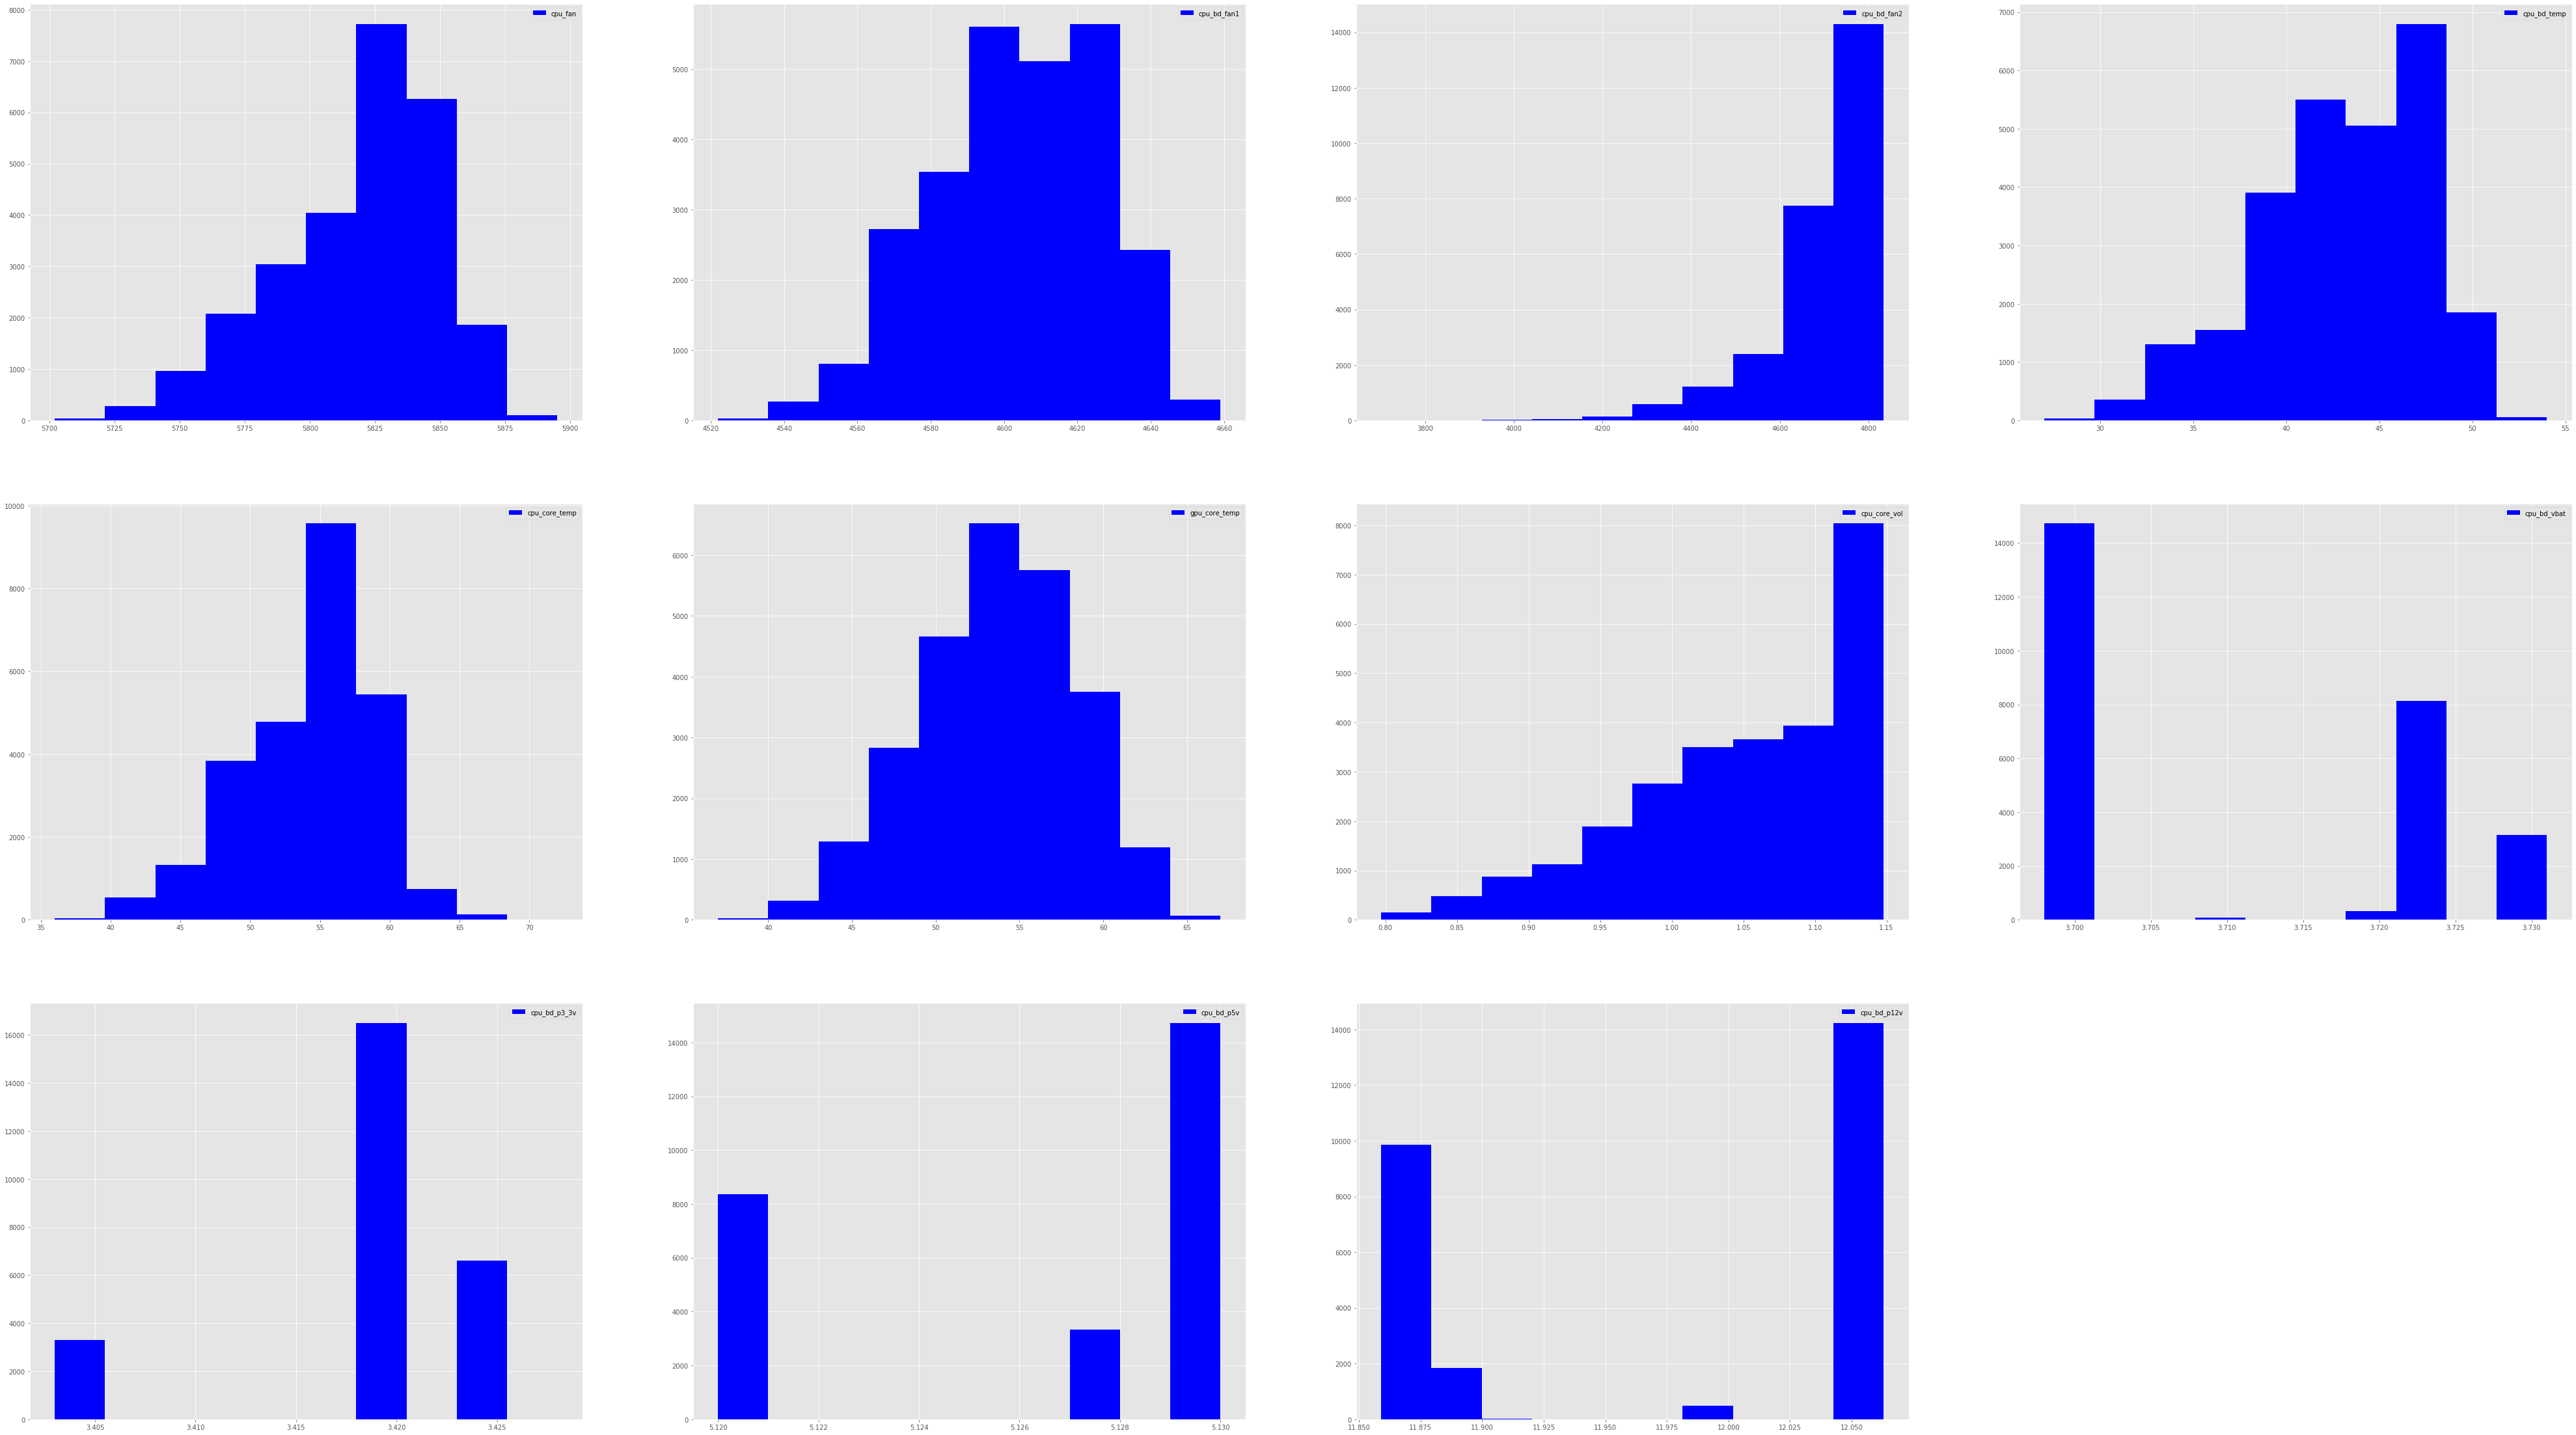

In [27]:
fig = plt.figure(figsize=(70,40))
column_list=["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"]

column_list2=["cpu_fan","cpu_bd_fan1"
             ,"cpu_bd_fan2","cpu_bd_temp"
             ,"cpu_core_temp","gpu_core_temp"
             ,"cpu_core_vol","cpu_bd_vbat"
             ,"cpu_bd_p3_3v","cpu_bd_p5v"
             ,"cpu_bd_p12v"]

check_hist=data_ADP555[data_ADP555["id"]=="9748019T-325"]

for i,label in enumerate(column_list):
    ax = fig.add_subplot(3,4,i+1)
    ax.hist(check_hist[label], color="b", label=column_list2[i] ,bins=10)
    ax.legend()

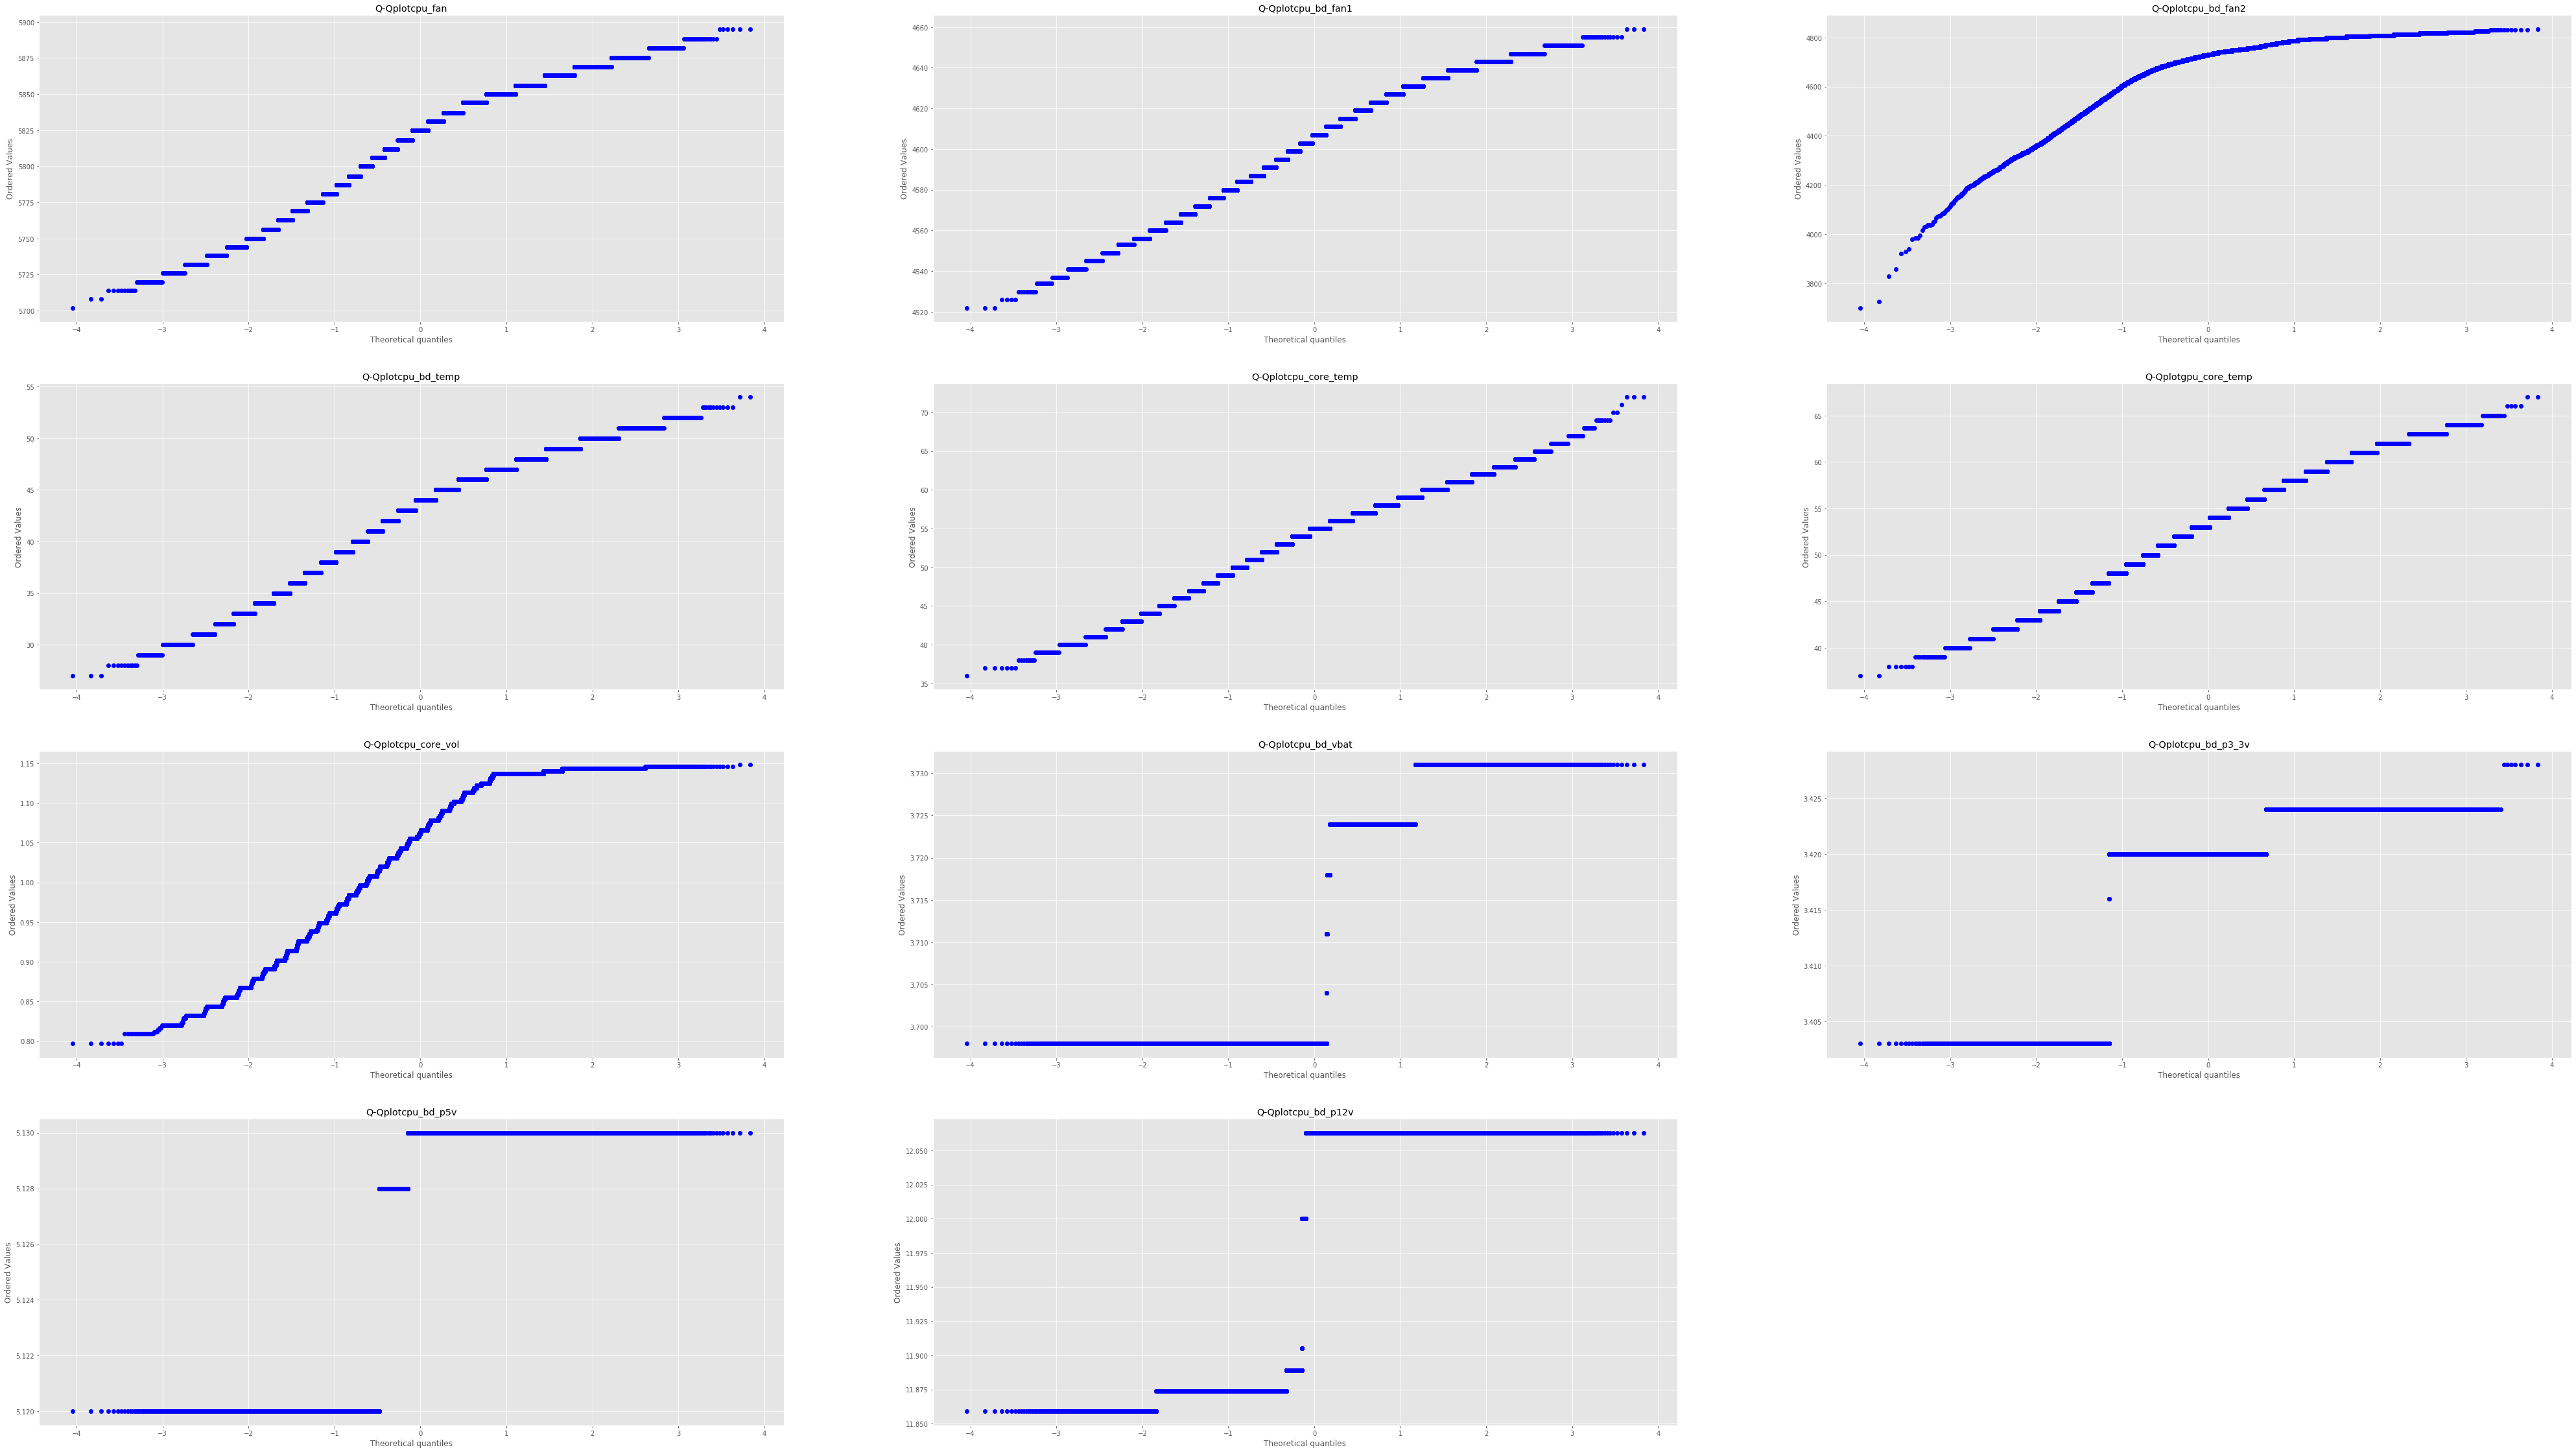

In [28]:
fig = plt.figure(figsize=(70,40))
column_list=["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"]

column_list2=["cpu_fan","cpu_bd_fan1"
             ,"cpu_bd_fan2","cpu_bd_temp"
             ,"cpu_core_temp","gpu_core_temp"
             ,"cpu_core_vol","cpu_bd_vbat"
             ,"cpu_bd_p3_3v","cpu_bd_p5v"
             ,"cpu_bd_p12v"]

check_hist=data_ADP555[data_ADP555["id"]=="9748019T-325"]

for i,label in enumerate(column_list):
    ax = fig.add_subplot(4,3,i+1)
    stats.probplot(check_hist[label], dist="norm", plot=plt)
    ax.set_title("Q-Qplot" + str(column_list2[i]))

No handles with labels found to put in legend.


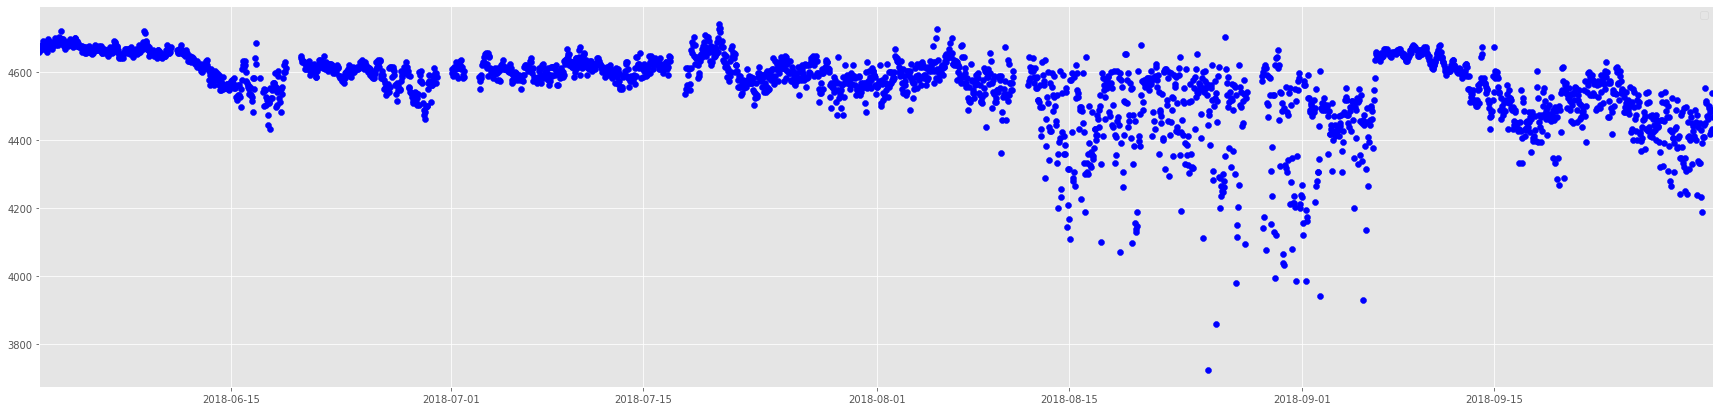

In [29]:
#期間初め
start_day=pd.to_datetime("2018/06/01 00:00:00", format='%Y/%m/%d %H:%M:%S')
#期間終わり
end_day=pd.to_datetime("2018/10/1 00:00:00", format='%Y/%m/%d %H:%M:%S')
test_select_df = check_hist[(check_hist["measurement_date"]>=start_day)&(check_hist["measurement_date"]<end_day)]

time = pd.to_datetime(test_select_df["measurement_date"], format='%Y/%m/%d %H:%M:%S')

fig = plt.figure(figsize=(30,7))
ax1 = fig.add_subplot(1,1,1)
ax1.scatter(time,test_select_df["processor_unit_units_status_cpu_board_cpu_bd_fan2"], color='blue')
ax1.set_xlim(time.min(),time.max())
ax1.legend()

# OCSVM & MT   CPU型式 ADP-555
## パラメータ　Cの分子:1000　γ:0.1

In [30]:
Select_id_data_set=data_ADP555[data_ADP555["id"]=="9748019T-325"]
colums_list=["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"]

In [31]:
Select_id_data_set

,id,equipment_label_no,f_shipno,measurement_date,processor_unit_units_hardware_info_serial_number_cpu_bd,monitor1_units_unit,monitor2_units_unit,measurement_ymd,measurement_ymd_h,measurement_ymd_hms,...,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_storage_device_wearout_ind,processor_unit_units_status_boot_device_wearout_ind,order,tag
1038152,9748019T-325,325,9748019T,2015-12-22 06:15:00,O14K5041,MU-190,MU-190,2015-12-22,06,2015-12-22 06:00:00,...,3.711,3.420,5.120,11.874,4599.0,4724.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038154,9748019T-325,325,9748019T,2015-12-22 07:00:02,O14K5041,MU-190,MU-190,2015-12-22,07,2015-12-22 07:00:00,...,3.704,3.420,5.120,11.859,4611.0,4736.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038155,9748019T-325,325,9748019T,2015-12-22 08:00:03,O14K5041,MU-190,MU-190,2015-12-22,08,2015-12-22 08:00:00,...,3.704,3.424,5.120,11.874,4599.0,4753.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038156,9748019T-325,325,9748019T,2015-12-22 09:00:03,O14K5041,MU-190,MU-190,2015-12-22,09,2015-12-22 09:00:00,...,3.704,3.420,5.120,11.874,4599.0,4749.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038157,9748019T-325,325,9748019T,2015-12-22 10:00:03,O14K5041,MU-190,MU-190,2015-12-22,10,2015-12-22 10:00:00,...,3.711,3.420,5.128,11.874,4587.0,4749.0,NaN,NaN,1.0,9748019T-325-2015-12-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064736,9748019T-325,325,9748019T,2019-02-04 19:00:02,O14K5041,NaN,NaN,2019-02-04,19,2019-02-04 19:00:00,...,3.698,3.420,5.130,12.063,4572.0,4481.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064737,9748019T-325,325,9748019T,2019-02-04 20:00:02,O14K5041,NaN,NaN,2019-02-04,20,2019-02-04 20:00:00,...,3.698,3.403,5.130,12.063,4572.0,4599.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064738,9748019T-325,325,9748019T,2019-02-04 21:00:02,O14K5041,NaN,NaN,2019-02-04,21,2019-02-04 21:00:00,...,3.698,3.420,5.130,12.063,4560.0,4568.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064739,9748019T-325,325,9748019T,2019-02-04 22:00:02,O14K5041,NaN,NaN,2019-02-04,22,2019-02-04 22:00:00,...,3.698,3.420,5.130,12.063,4572.0,4522.0,NaN,NaN,1.0,9748019T-325-2019-02-04


# モデル開始


In [32]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.simplefilter('ignore')     

import math
import os

# 保存先
ans_data_set_no_cor=pd.DataFrame()

data_OCSVM = Select_id_data_set[colums_list+["measurement_date"]]
data_OCSVM=data_OCSVM.reset_index(drop = True)
Select_data=data_OCSVM["measurement_date"][0]

train_start_year=Select_data.year
train_start_month=Select_data.month
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"
print(train_start_data)
# パラメータ
NU=0.01
gam=0.1
data_OCSVM=data_OCSVM.dropna(how='any')
data_OCSVM=data_OCSVM.reset_index(drop = True)

data_OCSVM["measurement_date"]=pd.to_datetime(data_OCSVM["measurement_date"], format='%Y/%m/%d %H:%M:%S')
for_times=1

2022/12/13 23:47
2015/12/01 00:00:00
Wall time: 31.2 ms


In [33]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_1=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_1 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_1.fit(train_OCSVM)
pre_train=model_ADP555_1.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_1.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_1.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_1=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_1)!=0:
        dt_anormaly_list_1=dt_anormaly_list_1[[0,1,2,3,4,5,6,7,8,9,10]]     
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_1=pd.concat([ADP555_select_id_1,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル1-----------------------------
OCSVMトレーニング期間開始 2015/12/01 00:00:00
OCSVMトレーニング期間終了 2017/12/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.01%
データ数 16602
サポートベクター数 170 

OCSVMテスト期間開始 2017/12/01 00:00:00
OCSVMテスト期間終了 2018/1/01 00:00:00
テストデータ数： 740
Wall time: 312 ms


In [34]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_2=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_2 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_2.fit(train_OCSVM)
pre_train=model_ADP555_2.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_2.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_2.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_2=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_2)!=0:
        dt_anormaly_list_2=dt_anormaly_list_2[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_2=pd.concat([ADP555_select_id_2,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル2-----------------------------
OCSVMトレーニング期間開始 2016/1/01 00:00:00
OCSVMトレーニング期間終了 2018/1/01 00:00:00
設定異常割合：1.00% 		学習異常割合：0.99%
データ数 17133
サポートベクター数 174 

OCSVMテスト期間開始 2018/1/01 00:00:00
OCSVMテスト期間終了 2018/2/01 00:00:00
テストデータ数： 744
Wall time: 328 ms


In [35]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_3=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_3 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_3.fit(train_OCSVM)
pre_train=model_ADP555_3.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_3.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_3.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_3=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_3)!=0:
        dt_anormaly_list_3=dt_anormaly_list_3[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_3=pd.concat([ADP555_select_id_3,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル3-----------------------------
OCSVMトレーニング期間開始 2016/2/01 00:00:00
OCSVMトレーニング期間終了 2018/2/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.01%
データ数 17133
サポートベクター数 174 

OCSVMテスト期間開始 2018/2/01 00:00:00
OCSVMテスト期間終了 2018/3/01 00:00:00
テストデータ数： 670
Wall time: 281 ms


In [36]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_4=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_4 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_4.fit(train_OCSVM)
pre_train=model_ADP555_4.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_4.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_4.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_4=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_4)!=0:
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_4=pd.concat([ADP555_select_id_4,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル4-----------------------------
OCSVMトレーニング期間開始 2016/3/01 00:00:00
OCSVMトレーニング期間終了 2018/3/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17107
サポートベクター数 174 

OCSVMテスト期間開始 2018/3/01 00:00:00
OCSVMテスト期間終了 2018/4/01 00:00:00
テストデータ数： 743
Wall time: 297 ms


In [37]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_5=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_5 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_5.fit(train_OCSVM)
pre_train=model_ADP555_5.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_5.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_5.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_5=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_5)!=0:
        dt_anormaly_list_5=dt_anormaly_list_5[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_5=pd.concat([ADP555_select_id_5,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル5-----------------------------
OCSVMトレーニング期間開始 2016/4/01 00:00:00
OCSVMトレーニング期間終了 2018/4/01 00:00:00
設定異常割合：1.00% 		学習異常割合：0.99%
データ数 17106
サポートベクター数 174 

OCSVMテスト期間開始 2018/4/01 00:00:00
OCSVMテスト期間終了 2018/5/01 00:00:00
テストデータ数： 719
Wall time: 406 ms


In [38]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_6=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_6 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_6.fit(train_OCSVM)
pre_train=model_ADP555_6.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_6.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_6.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_6=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_6)!=0:
        dt_anormaly_list_6=dt_anormaly_list_6[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_6=pd.concat([ADP555_select_id_6,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル6-----------------------------
OCSVMトレーニング期間開始 2016/5/01 00:00:00
OCSVMトレーニング期間終了 2018/5/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17154
サポートベクター数 176 

OCSVMテスト期間開始 2018/5/01 00:00:00
OCSVMテスト期間終了 2018/6/01 00:00:00
テストデータ数： 719
Wall time: 305 ms


In [39]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_7=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_7 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_7.fit(train_OCSVM)
pre_train=model_ADP555_7.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_7.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_7.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_7=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_7)!=0:
        dt_anormaly_list_7=dt_anormaly_list_7[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_7=pd.concat([ADP555_select_id_7,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル7-----------------------------
OCSVMトレーニング期間開始 2016/6/01 00:00:00
OCSVMトレーニング期間終了 2018/6/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.01%
データ数 17161
サポートベクター数 174 

OCSVMテスト期間開始 2018/6/01 00:00:00
OCSVMテスト期間終了 2018/7/01 00:00:00
テストデータ数： 650
Wall time: 281 ms


In [40]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_8=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_8 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_8.fit(train_OCSVM)
pre_train=model_ADP555_8.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_8.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_8.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_8=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_8)!=0:
        dt_anormaly_list_8=dt_anormaly_list_8[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_8=pd.concat([ADP555_select_id_8,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル8-----------------------------
OCSVMトレーニング期間開始 2016/7/01 00:00:00
OCSVMトレーニング期間終了 2018/7/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.01%
データ数 17141
サポートベクター数 176 

OCSVMテスト期間開始 2018/7/01 00:00:00
OCSVMテスト期間終了 2018/8/01 00:00:00
テストデータ数： 693
Wall time: 312 ms


In [41]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_9=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_9 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_9.fit(train_OCSVM)
pre_train=model_ADP555_9.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_9.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_9.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_9=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_9)!=0:
        dt_anormaly_list_9=dt_anormaly_list_9[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_9=pd.concat([ADP555_select_id_9,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル9-----------------------------
OCSVMトレーニング期間開始 2016/8/01 00:00:00
OCSVMトレーニング期間終了 2018/8/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17129
サポートベクター数 176 

OCSVMテスト期間開始 2018/8/01 00:00:00
OCSVMテスト期間終了 2018/9/01 00:00:00
テストデータ数： 694
Wall time: 281 ms


In [42]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_10=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_10 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_10.fit(train_OCSVM)
pre_train=model_ADP555_10.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_10.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_10.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_10=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_10)!=0:
        dt_anormaly_list_10=dt_anormaly_list_10[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_10=pd.concat([ADP555_select_id_10,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル10-----------------------------
OCSVMトレーニング期間開始 2016/9/01 00:00:00
OCSVMトレーニング期間終了 2018/9/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17079
サポートベクター数 173 

OCSVMテスト期間開始 2018/9/01 00:00:00
OCSVMテスト期間終了 2018/10/01 00:00:00
テストデータ数： 720
Test PASS
Wall time: 473 ms


In [43]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_11=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_11 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_11.fit(train_OCSVM)
pre_train=model_ADP555_11.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_11.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_11.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_11=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_11)!=0:
        dt_anormaly_list_11=dt_anormaly_list_11[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_11=pd.concat([ADP555_select_id_11,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル11-----------------------------
OCSVMトレーニング期間開始 2016/10/01 00:00:00
OCSVMトレーニング期間終了 2018/10/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17128
サポートベクター数 175 

OCSVMテスト期間開始 2018/10/01 00:00:00
OCSVMテスト期間終了 2018/11/01 00:00:00
テストデータ数： 695
Wall time: 383 ms


In [44]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_12=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_12 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_12.fit(train_OCSVM)
pre_train=model_ADP555_12.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_12.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_12.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_12=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_12)!=0:
        dt_anormaly_list_12=dt_anormaly_list_12[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_12=pd.concat([ADP555_select_id_12,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル12-----------------------------
OCSVMトレーニング期間開始 2016/11/01 00:00:00
OCSVMトレーニング期間終了 2018/11/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 17079
サポートベクター数 174 

OCSVMテスト期間開始 2018/11/01 00:00:00
OCSVMテスト期間終了 2018/12/01 00:00:00
テストデータ数： 527
Wall time: 297 ms


In [45]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_13=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_13 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_13.fit(train_OCSVM)
pre_train=model_ADP555_13.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_13.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_13.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_13=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_13)!=0:
        dt_anormaly_list_13=dt_anormaly_list_13[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_13=pd.concat([ADP555_select_id_13,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル13-----------------------------
OCSVMトレーニング期間開始 2016/12/01 00:00:00
OCSVMトレーニング期間終了 2018/12/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 16936
サポートベクター数 173 

OCSVMテスト期間開始 2018/12/01 00:00:00
OCSVMテスト期間終了 2019/1/01 00:00:00
テストデータ数： 669
Wall time: 297 ms


In [46]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_14=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_14 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_14.fit(train_OCSVM)
pre_train=model_ADP555_14.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_14.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_14.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_14=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_14)!=0:
        dt_anormaly_list_14=dt_anormaly_list_14[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_14=pd.concat([ADP555_select_id_14,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル14-----------------------------
OCSVMトレーニング期間開始 2017/1/01 00:00:00
OCSVMトレーニング期間終了 2019/1/01 00:00:00
設定異常割合：1.00% 		学習異常割合：0.98%
データ数 16861
サポートベクター数 171 

OCSVMテスト期間開始 2019/1/01 00:00:00
OCSVMテスト期間終了 2019/2/01 00:00:00
テストデータ数： 744
Wall time: 258 ms


In [47]:
%%time
import time
now = time.ctime()
cnvtime = time.strptime(now)
print(time.strftime("%Y/%m/%d %H:%M", cnvtime))

# スタートの傾き・モデル作成
print("-------------------------モデル"+str(for_times)+"-----------------------------")

train_start_month=train_start_month+1
if train_start_month>12:
    train_start_month=train_start_month-12
    train_start_year+=1
train_start_data=str(train_start_year)+"/"+str(train_start_month)+"/01 00:00:00"

train_end_month=train_start_month
train_end_year=train_start_year+2
if train_end_month>12:
    train_end_month=train_end_month-12
    train_end_year=train_end_year+1
train_end_data=str(train_end_year)+"/"+str(train_end_month)+"/01 00:00:00"

model_data=data_OCSVM[(data_OCSVM["measurement_date"]>=train_start_data)&(data_OCSVM["measurement_date"]<train_end_data)]

print("OCSVMトレーニング期間開始",train_start_data)
print("OCSVMトレーニング期間終了",train_end_data)

model_data=model_data[colums_list]
model_data=model_data.values

ADP555_select_id_15=pd.DataFrame()

mm_ADP555 = preprocessing.MinMaxScaler()
train_OCSVM = mm_ADP555.fit_transform((model_data).reshape(len(model_data), -1))
train_OCSVM += 0.0001

model_ADP555_15 = svm.OneClassSVM(nu=NU,gamma=gam,kernel="rbf")
model_ADP555_15.fit(train_OCSVM)
pre_train=model_ADP555_15.predict(train_OCSVM)
print("設定異常割合：{:.2%}".format(NU),"\t\t学習異常割合：{:.2%}".format(len(pre_train[pre_train<0])/len(train_OCSVM)))
# print("傾き",model_ADP555.coef_)
# print("切片",model_ADP555.intercept_)
print("データ数",len(train_OCSVM))
print("サポートベクター数",len(model_ADP555_15.support_vectors_),"\n")

#------------------------------------------------------------------------
test_start_data=train_end_data
test_end_month=train_end_month
test_end_year=train_end_year

if test_end_month==12:
    test_end_month=1
    test_end_year=train_end_year+1
else:
    test_end_month=test_end_month+1
    
test_end_data=str(test_end_year)+"/"+str(test_end_month)+"/01 00:00:00"

test_data=data_OCSVM[(data_OCSVM["measurement_date"]>=test_start_data)&(data_OCSVM["measurement_date"]<test_end_data)]
print("OCSVMテスト期間開始",test_start_data)
print("OCSVMテスト期間終了",test_end_data)

if len(test_data)!=0:
    data_set=test_data[["measurement_date"]+colums_list].reset_index(drop = True)
    test_data=test_data[colums_list].reset_index(drop = True)
    test_data=test_data.values


    test_OCSVM = mm_ADP555.transform((test_data).reshape(len(test_data), -1))
    test_OCSVM += 0.0001
    print("テストデータ数：",len(test_OCSVM))
    MinMax_data=pd.DataFrame(test_OCSVM)
    score_set_OCSVM=model_ADP555_15.decision_function(test_OCSVM)*(-1)
    score_set_OCSVM=pd.DataFrame(score_set_OCSVM)
    MinMax_data["score_abnormal_OCSVM"]=score_set_OCSVM[0]
    
    dt_anormaly_list_15=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    
    index_num=MinMax_data[(MinMax_data["score_abnormal_OCSVM"]>0)]
    index_num=index_num.index
    
     
    if len(dt_anormaly_list_15)!=0:
        dt_anormaly_list_15=dt_anormaly_list_15[[0,1,2,3,4,5,6,7,8,9,10]]
        
        data_set["processor_unit_units_status_cpu_board_cpu_fan"]= MinMax_data[0]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"]= MinMax_data[1]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"]= MinMax_data[2]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"]= MinMax_data[3]
        data_set["processor_unit_units_status_cpu_board_cpu_core_temp"]= MinMax_data[4]
        data_set["processor_unit_units_status_cpu_board_gpu_core_temp"]= MinMax_data[5]
        data_set["processor_unit_units_status_cpu_board_cpu_core_vol"]= MinMax_data[6]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"]= MinMax_data[7]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"]= MinMax_data[8]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"]= MinMax_data[9]
        data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"]= MinMax_data[10]


        
        data_set=data_set.sort_values("measurement_date").reset_index(drop=True)
    

        dt_anormaly = pd.DataFrame({"measurement_date": data_set["measurement_date"],
                                    "processor_unit_units_status_cpu_board_cpu_fan": data_set["processor_unit_units_status_cpu_board_cpu_fan"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan1": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan1"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_fan2": data_set["processor_unit_units_status_cpu_board_cpu_bd_fan2"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_temp": data_set["processor_unit_units_status_cpu_board_cpu_bd_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_temp": data_set["processor_unit_units_status_cpu_board_cpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_gpu_core_temp": data_set["processor_unit_units_status_cpu_board_gpu_core_temp"],
                                    "processor_unit_units_status_cpu_board_cpu_core_vol": data_set["processor_unit_units_status_cpu_board_cpu_core_vol"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_vbat": data_set["processor_unit_units_status_cpu_board_cpu_bd_vbat"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p3_3v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p3_3v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p5v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p5v"],
                                    "processor_unit_units_status_cpu_board_cpu_bd_p12v": data_set["processor_unit_units_status_cpu_board_cpu_bd_p12v"],
                                    "MM_cpu_fan": MinMax_data[0],
                                    "MM_cpu_bd_fan1": MinMax_data[1],
                                    "MM_cpu_bd_fan2": MinMax_data[2],
                                    "MM_cpu_bd_temp": MinMax_data[3],
                                    "MM_cpu_core_temp": MinMax_data[4],
                                    "MM_gpu_core_temp": MinMax_data[5],
                                    "MM_cpu_core_vol": MinMax_data[6],
                                    "MM_cpu_bd_vbat": MinMax_data[7],
                                    "MM_cpu_bd_p3_3v": MinMax_data[8],
                                    "MM_cpu_bd_p5v": MinMax_data[9],
                                    "MM_cpu_bd_p12v": MinMax_data[10],
                                    "score_abnormal_OCSVM":score_set_OCSVM[0]
                                    }).reset_index(drop = True)
    
        ADP555_select_id_15=pd.concat([ADP555_select_id_15,dt_anormaly], ignore_index=True)
    else:
        print("Test PASS")
else:
    print("Test PASS")
for_times=for_times+1

2022/12/13 23:47
-------------------------モデル15-----------------------------
OCSVMトレーニング期間開始 2017/2/01 00:00:00
OCSVMトレーニング期間終了 2019/2/01 00:00:00
設定異常割合：1.00% 		学習異常割合：1.00%
データ数 16861
サポートベクター数 171 

OCSVMテスト期間開始 2019/2/01 00:00:00
OCSVMテスト期間終了 2019/3/01 00:00:00
テストデータ数： 96
Test PASS
Wall time: 248 ms


In [48]:
ADP555_select_id_ALL=pd.concat([ADP555_select_id_1,ADP555_select_id_2,ADP555_select_id_3,ADP555_select_id_4,ADP555_select_id_5
                               ,ADP555_select_id_6,ADP555_select_id_7,ADP555_select_id_8,ADP555_select_id_9,ADP555_select_id_10
                               ,ADP555_select_id_11,ADP555_select_id_12,ADP555_select_id_13,ADP555_select_id_14,ADP555_select_id_15], ignore_index=False)

In [49]:
ADP555_select_id_ALL.head(3)

,measurement_date,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,MM_cpu_fan,MM_cpu_bd_fan1,MM_cpu_bd_fan2,MM_cpu_bd_temp,MM_cpu_core_temp,MM_gpu_core_temp,MM_cpu_core_vol,MM_cpu_bd_vbat,MM_cpu_bd_p3_3v,MM_cpu_bd_p5v,MM_cpu_bd_p12v,score_abnormal_OCSVM
0,2017-12-01 00:00:03,0.361047,0.474553,0.315371,0.4001,0.382453,0.296396,0.900385,0.0001,0.0001,1.0001,1.0001,0.361047,0.474553,0.315371,0.4001,0.382453,0.296396,0.900385,0.0001,0.0001,1.0001,1.0001,-2.170724
1,2017-12-01 01:00:02,0.396550,0.503750,0.335075,0.4401,0.529512,0.370470,0.800670,0.0001,0.0001,1.0001,1.0001,0.396550,0.503750,0.335075,0.4401,0.529512,0.370470,0.800670,0.0001,0.0001,1.0001,1.0001,-3.105997
2,2017-12-01 02:00:02,0.437970,0.532947,0.418819,0.4801,0.441276,0.407507,0.666767,0.0001,0.6801,1.0001,1.0001,0.437970,0.532947,0.418819,0.4801,0.441276,0.407507,0.666767,0.0001,0.6801,1.0001,1.0001,-7.043404


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


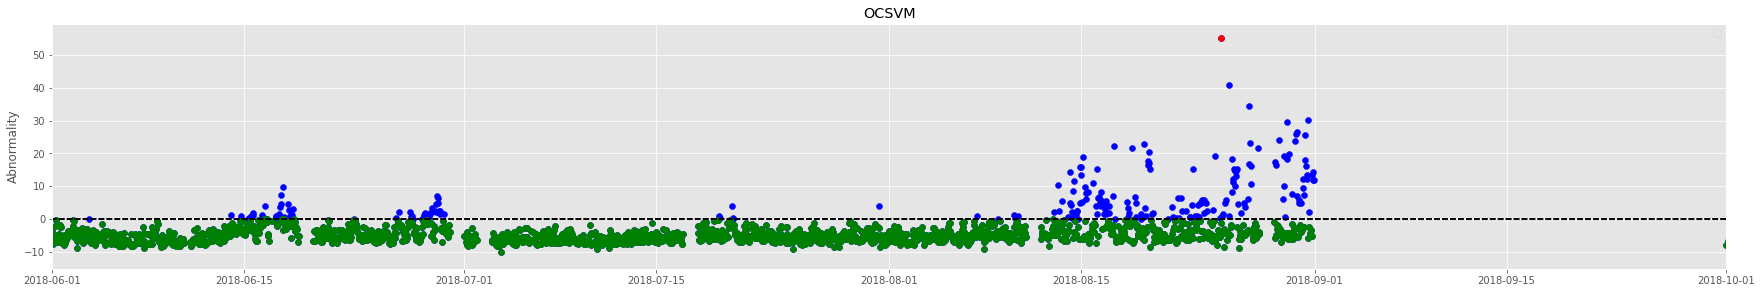

In [50]:
time = pd.to_datetime(ADP555_select_id_ALL["measurement_date"], format='%Y/%m/%d %H:%M:%S')
time_min=pd.to_datetime("2018/06/01 00:00:00", format='%Y/%m/%d %H:%M:%S')
time_max=pd.to_datetime("2018/10/01 00:00:00", format='%Y/%m/%d %H:%M:%S')

fig = plt.figure(figsize=(30,4.5))
ax1 = fig.add_subplot(1,1,1)
ax1.set_title("OCSVM")
ax1.scatter(time,ADP555_select_id_ALL["score_abnormal_OCSVM"], color='blue')
ax1.set_ylabel('Abnormality')
ax1.hlines(0,time_max,time_min, color='black',linestyles='dashed')
ax1.set_xlim(time_min,time_max)
ax1.legend()



ab_select= ADP555_select_id_ALL[ADP555_select_id_ALL["score_abnormal_OCSVM"]<0]
time1=pd.to_datetime(ab_select["measurement_date"], format='%Y/%m/%d %H:%M:%S')

ax1 = fig.add_subplot(1,1,1)
ax1.set_title("OCSVM")
ax1.scatter(time1,ab_select["score_abnormal_OCSVM"], color='green')
ax1.set_ylabel('Abnormality')
ax1.hlines(0,time_max,time_min, color='black',linestyles='dashed')
ax1.set_xlim(time_min,time_max)
ax1.legend()


time2=pd.to_datetime("2018/08/25 04:00:03", format='%Y/%m/%d %H:%M:%S')
select_dt= ADP555_select_id_ALL[ADP555_select_id_ALL["measurement_date"]==time2]

ax1 = fig.add_subplot(1,1,1)
ax1.set_title("OCSVM")
ax1.scatter(time2,select_dt["score_abnormal_OCSVM"], color='red')
ax1.set_ylabel('Abnormality')
ax1.hlines(0,time_max,time_min, color='black',linestyles='dashed')
ax1.set_xlim(time_min,time_max)
ax1.legend()

# 期間選択

In [51]:
#期間初め
start_day=pd.to_datetime("2018/7/01 00:00:00", format='%Y/%m/%d %H:%M:%S')
#期間終わり
end_day=pd.to_datetime("2018/8/01 00:00:00", format='%Y/%m/%d %H:%M:%S')

ab_select_df = ADP555_select_id_ALL[ADP555_select_id_ALL["score_abnormal_OCSVM"]>0]
ab_select_df = ab_select_df[(ab_select_df["measurement_date"]>=start_day)&(ab_select_df["measurement_date"]<end_day)]
print(len(ab_select_df))
ab_select_df[["measurement_date","score_abnormal_OCSVM"]]

7


,measurement_date,score_abnormal_OCSVM
395,2018-07-19 14:00:03,0.832926
396,2018-07-19 15:00:02,0.368352
397,2018-07-19 16:00:03,0.308384
418,2018-07-20 13:00:03,3.886756
419,2018-07-20 14:00:02,0.395920
420,2018-07-20 15:00:03,0.087660
675,2018-07-31 06:00:03,3.866879


In [52]:
Select_id_data_set["measurement_date"] = pd.to_datetime(Select_id_data_set["measurement_date"], format='%Y/%m/%d %H:%M:%S')
Select_id_data_set[Select_id_data_set["measurement_date"]=="2018/11/21 04:00:03"][["measurement_date"]+colums_list]

,measurement_date,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v
1063139,2018-11-21 04:00:03,5800.0,4584.0,3701.0,41.0,52.0,50.0,1.043,3.698,3.42,5.13,12.063


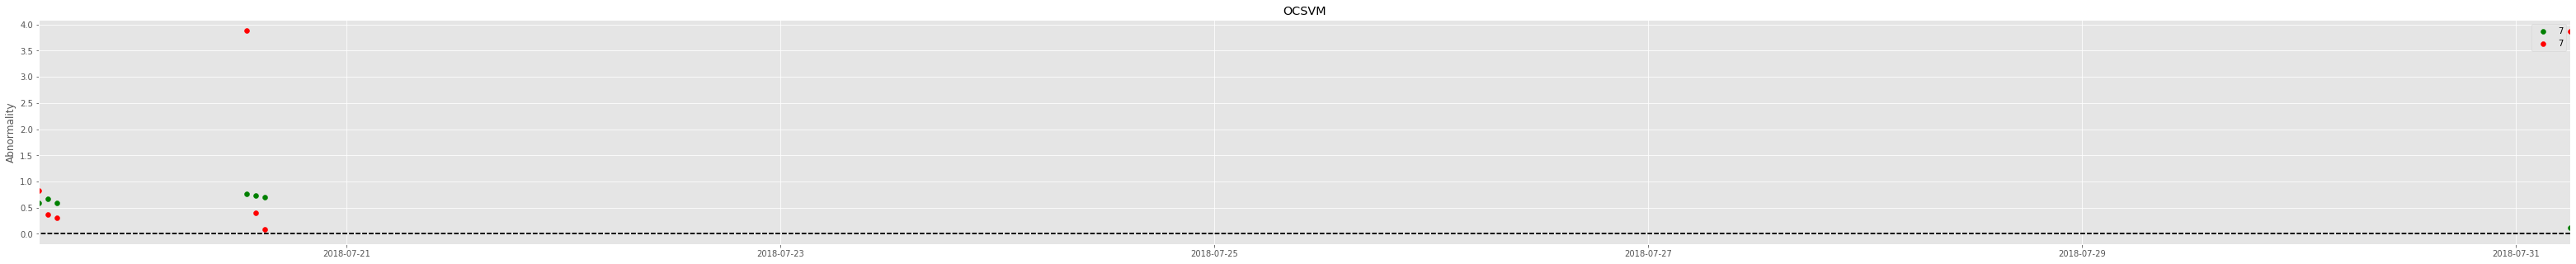

In [53]:
time_a = pd.to_datetime(ab_select_df["measurement_date"], format='%Y/%m/%d %H:%M:%S')

fig = plt.figure(figsize=(55,5))
ax1 = fig.add_subplot(1,1,1)
ax1.set_title("OCSVM")
ax1.scatter(time_a,ab_select_df["processor_unit_units_status_cpu_board_cpu_bd_fan2"], color='green',label=len(ab_select_df["score_abnormal_OCSVM"]))
ax1.set_ylabel('Abnormality')
ax1.hlines(0,time_a.max(),time_a.min(), color='black',linestyles='dashed')
ax1.set_xlim(time_a.min(),time_a.max())
ax1.legend()


# ab_select= ADP555_select_id_ALL[ADP555_select_id_ALL["measurement_date"]=="2018/8/25  4:00:03"]
ab_select= ab_select_df[ab_select_df["score_abnormal_OCSVM"]>0]
time1=pd.to_datetime(ab_select["measurement_date"], format='%Y/%m/%d %H:%M:%S')

ax1 = fig.add_subplot(1,1,1)
ax1.set_title("OCSVM")
ax1.scatter(time1,ab_select["score_abnormal_OCSVM"], color='red',label=len(ab_select["score_abnormal_OCSVM"]))
ax1.set_ylabel('Abnormality')
ax1.hlines(0,time_a.max(),time_a.min(), color='black',linestyles='dashed')
ax1.set_xlim(time_a.min(),time_a.max())
ax1.legend()

In [54]:
ADP555_select_id_ALL.sort_values("score_abnormal_OCSVM",ascending=False).head(20)

,measurement_date,processor_unit_units_status_cpu_board_cpu_fan,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_cpu_board_cpu_bd_temp,processor_unit_units_status_cpu_board_cpu_core_temp,processor_unit_units_status_cpu_board_gpu_core_temp,processor_unit_units_status_cpu_board_cpu_core_vol,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,MM_cpu_fan,MM_cpu_bd_fan1,MM_cpu_bd_fan2,MM_cpu_bd_temp,MM_cpu_core_temp,MM_gpu_core_temp,MM_cpu_core_vol,MM_cpu_bd_vbat,MM_cpu_bd_p3_3v,MM_cpu_bd_p5v,MM_cpu_bd_p12v,score_abnormal_OCSVM
555,2018-08-25 04:00:03,0.679658,0.690022,-1.762992,0.692408,0.600100,0.633433,0.233718,0.0001,0.6801,1.0001,1.0001,0.679658,0.690022,-1.762992,0.692408,0.600100,0.633433,0.233718,0.0001,0.6801,1.0001,1.0001,55.089668
569,2018-08-25 18:00:02,0.541536,0.596999,-1.431321,0.615485,0.514386,0.533433,0.834858,0.0001,0.6801,1.0001,1.0001,0.541536,0.596999,-1.431321,0.615485,0.514386,0.533433,0.834858,0.0001,0.6801,1.0001,1.0001,40.881175
604,2018-08-27 05:00:03,0.646509,0.596999,-1.132070,0.692408,0.600100,0.600100,0.000100,0.0001,0.6801,1.0001,1.0001,0.646509,0.596999,-1.132070,0.692408,0.600100,0.600100,0.000100,0.0001,0.6801,1.0001,1.0001,34.433933
683,2018-08-31 13:00:03,0.613360,0.596999,-1.117107,0.615485,0.571529,0.533433,0.900385,0.0001,0.6801,1.0001,1.0001,0.613360,0.596999,-1.117107,0.615485,0.571529,0.533433,0.900385,0.0001,0.6801,1.0001,1.0001,30.055982
646,2018-08-30 00:00:03,0.679658,0.690022,-1.094663,0.692408,0.542957,0.633433,0.532864,0.0001,0.6801,1.0001,1.0001,0.679658,0.690022,-1.094663,0.692408,0.542957,0.633433,0.532864,0.0001,0.6801,1.0001,1.0001,29.530898
663,2018-08-30 17:00:03,0.613360,0.628007,-0.999900,0.615485,0.657243,0.566767,0.367621,0.0001,0.6801,1.0001,1.0001,0.613360,0.628007,-0.999900,0.615485,0.657243,0.566767,0.367621,0.0001,0.6801,1.0001,1.0001,26.512090
661,2018-08-30 15:00:03,0.574686,0.628007,-0.984937,0.653946,0.542957,0.566767,0.968761,0.0001,0.6801,1.0001,1.0001,0.574686,0.628007,-0.984937,0.653946,0.542957,0.566767,0.968761,0.0001,0.6801,1.0001,1.0001,25.935943
677,2018-08-31 07:00:03,0.784630,0.814053,-0.877705,0.846254,0.685814,0.733433,0.367621,0.0001,0.6801,1.0001,1.0001,0.784630,0.814053,-0.877705,0.846254,0.685814,0.733433,0.367621,0.0001,0.6801,1.0001,1.0001,25.658852
631,2018-08-29 09:00:03,0.718332,0.721030,-0.885187,0.769331,0.742957,0.700100,0.567052,0.0001,0.6801,1.0001,1.0001,0.718332,0.721030,-0.885187,0.769331,0.742957,0.700100,0.567052,0.0001,0.6801,1.0001,1.0001,24.143078
660,2018-08-30 14:00:03,0.574686,0.659015,-0.915112,0.615485,0.628671,0.566767,0.968761,0.0001,0.6801,1.0001,1.0001,0.574686,0.659015,-0.915112,0.615485,0.628671,0.566767,0.968761,0.0001,0.6801,1.0001,1.0001,23.824450


In [55]:
data_OCSVM[["measurement_date","processor_unit_units_status_cpu_board_cpu_bd_fan2"]].sort_values("processor_unit_units_status_cpu_board_cpu_bd_fan2",ascending=True).head(20)

,measurement_date,processor_unit_units_status_cpu_board_cpu_bd_fan2
24848,2018-11-21 04:00:03,3701.0
22835,2018-08-25 04:00:03,3726.0
24847,2018-11-21 03:00:04,3829.0
22849,2018-08-25 18:00:02,3859.0
24846,2018-11-21 02:00:03,3921.0
23081,2018-09-05 11:00:03,3930.0
23005,2018-09-02 07:00:03,3941.0
22884,2018-08-27 05:00:03,3979.0
22980,2018-09-01 06:00:02,3985.0
22963,2018-08-31 13:00:03,3985.0


No handles with labels found to put in legend.
No handles with labels found to put in legend.


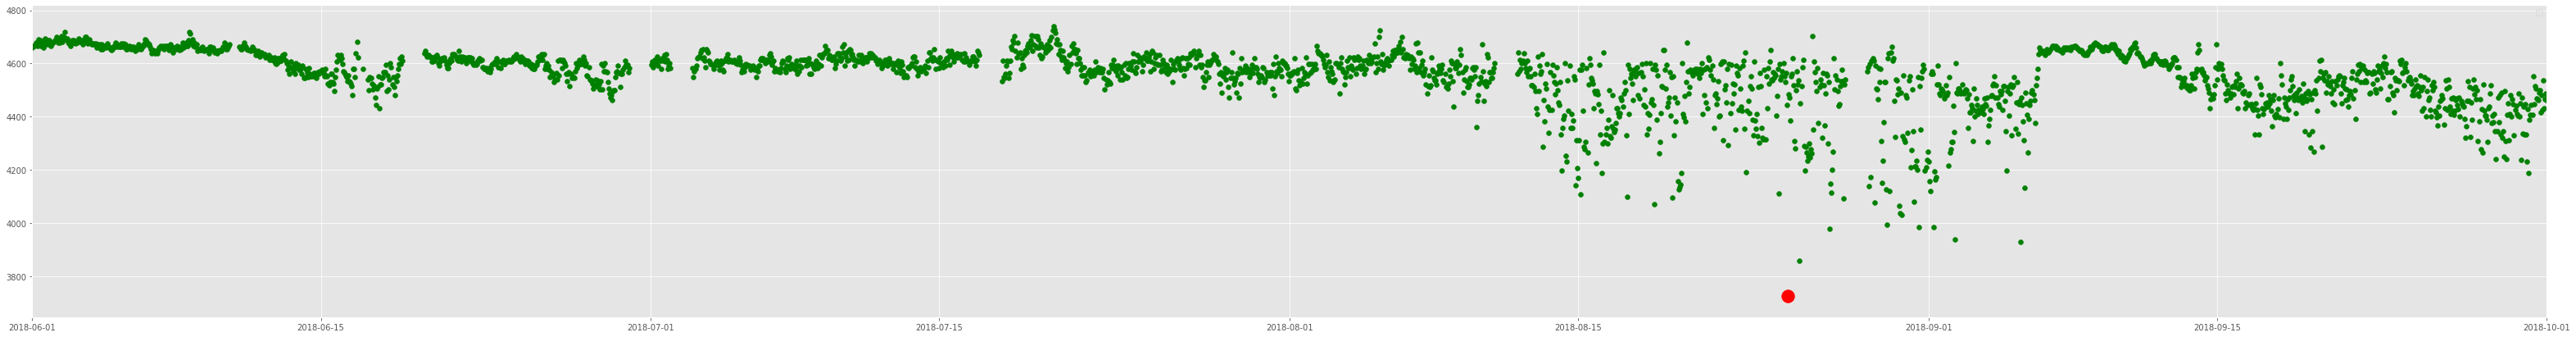

In [56]:
#期間初め
start_day=pd.to_datetime("2017/12/01 00:00:00", format='%Y/%m/%d %H:%M:%S')
#期間終わり
end_day=pd.to_datetime("2019/3/1 00:00:00", format='%Y/%m/%d %H:%M:%S')
test_select_df = data_OCSVM[(data_OCSVM["measurement_date"]>=start_day)&(data_OCSVM["measurement_date"]<end_day)]

min_time=pd.to_datetime("2018/6/1 00:00:00", format='%Y/%m/%d %H:%M:%S')
max_time=pd.to_datetime("2018/10/1 00:00:00", format='%Y/%m/%d %H:%M:%S')
time = pd.to_datetime(test_select_df["measurement_date"], format='%Y/%m/%d %H:%M:%S')

fig = plt.figure(figsize=(55,7))
ax1 = fig.add_subplot(1,1,1)
ax1.scatter(time,test_select_df["processor_unit_units_status_cpu_board_cpu_bd_fan2"], color='green')
ax1.set_xlim(min_time,max_time)
ax1.legend()
# (data_OCSVM["measurement_date"]=="2018/11/21 04:00:03")|
FG_select_df = data_OCSVM[(data_OCSVM["measurement_date"]=="2018/08/25 04:00:03")]
time1 = pd.to_datetime(FG_select_df["measurement_date"], format='%Y/%m/%d %H:%M:%S')
ax1 = fig.add_subplot(1,1,1)
ax1.scatter(time1,FG_select_df["processor_unit_units_status_cpu_board_cpu_bd_fan2"], color='red', s=250)
ax1.set_xlim(min_time,max_time)
ax1.legend()

In [57]:
#期間初め
start_day=pd.to_datetime("2018/7/22 00:00:00", format='%Y/%m/%d %H:%M:%S')
#期間終わり
end_day=pd.to_datetime("2018/8/25 04:00:00", format='%Y/%m/%d %H:%M:%S')
print(len(data_OCSVM[(data_OCSVM["measurement_date"]>=start_day)&(data_OCSVM["measurement_date"]<end_day)]))

795
